No local CSV with pit-stop target column found. Attempting Kaggle download...
Path to dataset files: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction
Loaded dataset from: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
Dataset name: f1_strategy_dataset_v4
Raw dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
Features after encoding: 73
Training XGBoost …
Training Random Forest …
Computing permutation importances (this may take a moment) …

=== Top-10 Feature Importances (XGBoost) ===
   1. Normalized_TyreLife   Importance=0.0988   ↳ 
   2. LapNumber             Importance=0.0595   ↳ 
   3. Stint                 Importance=0.0548   ↳ 
   4. Year                  Importance=0.0441   ↳ 
   5. Race

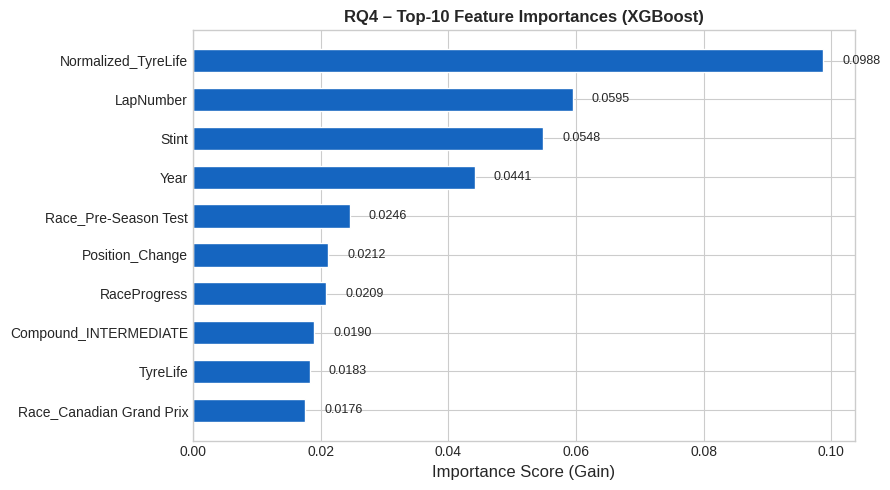

Figure saved → figures/RQ4_xgb_feature_importance.png


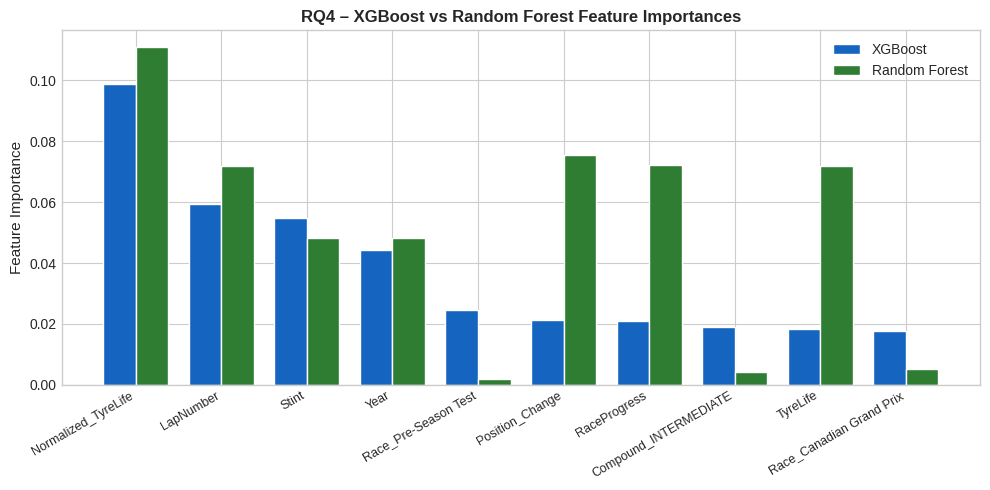

Figure saved → figures/RQ4_xgb_vs_rf_importance.png


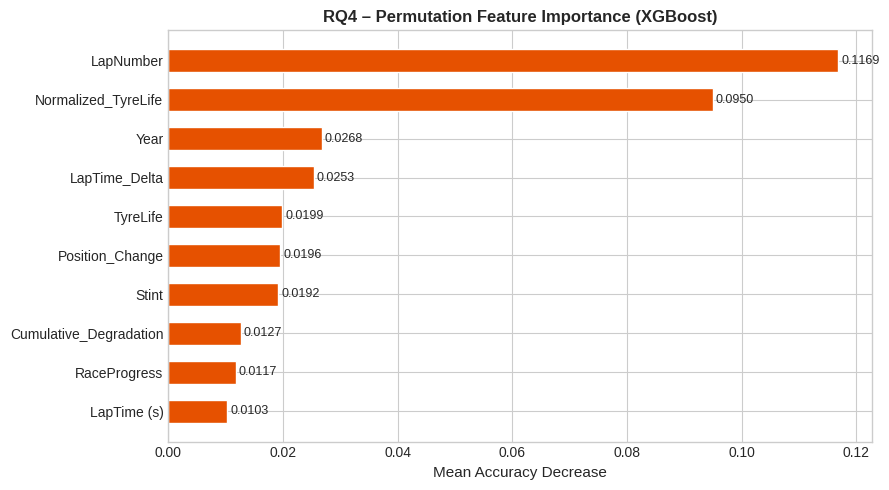

Figure saved → figures/RQ4_permutation_importance.png


KeyError: 'tyre_life'

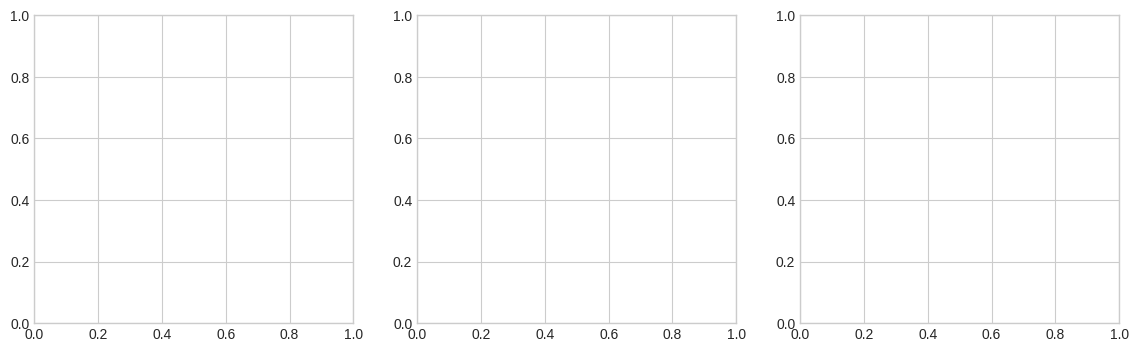

In [1]:
"""
RQ4: Which input features contribute most to pit-stop prediction,
     and what domain insights can be derived from the top-ranked features?
"""

try:
    import kagglehub
except ImportError:
    kagglehub = None
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#B71C1C", "#006064"]

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Prefer a local CSV file; fall back to Kaggle download only when needed.
local_csvs = sorted(glob.glob("*.csv"))
raw_path = None

csv_file = None
valid_targets = {"pit_stop", "PitStop", "pitstop", "pit stop"}
for candidate in local_csvs:
    try:
        sample = pd.read_csv(candidate, nrows=5)
    except Exception:
        continue
    if valid_targets.intersection(set(sample.columns.str.replace(" ", "").str.lower())):
        csv_file = candidate
        break

if csv_file is not None:
    print(f"Using local dataset file: {csv_file}")
else:
    if kagglehub is None:
        raise RuntimeError(
            "No local dataset CSV found and kagglehub is not installed. "
            "Please place the dataset CSV in this folder or install kagglehub to enable fallback download."
        )
    print("No local CSV with pit-stop target column found. Attempting Kaggle download...")
    try:
        raw_path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")
        print("Path to dataset files:", raw_path)
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Please place the dataset CSV in this folder or fix Kaggle SSL/authentication. "
            "If you have the CSV locally, name it something like 'f1_strategy.csv' and rerun."
        ) from exc

    if os.path.isfile(raw_path) and raw_path.lower().endswith(".zip"):
        extract_dir = os.path.splitext(raw_path)[0]
        if not os.path.exists(extract_dir):
            with zipfile.ZipFile(raw_path, "r") as archive:
                archive.extractall(extract_dir)
        data_dir = extract_dir
    else:
        data_dir = raw_path

    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in dataset path: {data_dir}")

    csv_file = sorted(csv_files)[0]

if csv_file is None:
    raise FileNotFoundError("No dataset CSV file could be loaded.")

df = pd.read_csv(csv_file)
dataset_name = os.path.splitext(os.path.basename(csv_file))[0]
print(f"Loaded dataset from: {csv_file}")
print(f"Dataset name: {dataset_name}")
print(f"Raw dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Standardize target column for pit-stop prediction.
found_target = None
for name in df.columns:
    nkey = name.replace(" ", "").replace("_", "").lower()
    if nkey == "pitstop":
        found_target = name
        break

if found_target is None:
    raise ValueError("Target column for pit-stop prediction not found in dataset")

if found_target != "pit_stop":
    df = df.rename(columns={found_target: "pit_stop"})
    found_target = "pit_stop"

# Encode non-numeric target if needed
if df["pit_stop"].dtype == object:
    df["pit_stop"], labels = pd.factorize(df["pit_stop"])
    print("Target encoding:", dict(enumerate(labels)))

# Drop rows with missing labels and keep only useful features
features = [c for c in df.columns if c != "pit_stop"]
X_df = df[features].copy()
X_df = pd.get_dummies(X_df, drop_first=True)

print(f"Features after encoding: {X_df.shape[1]}")

df = pd.concat([X_df, df[["pit_stop"]]], axis=1)

FEATURES = [c for c in df.columns if c != "pit_stop"]
X = df[FEATURES].values
y = df["pit_stop"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test) 
print("Training XGBoost …")
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                     eval_metric="logloss", random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

print("Training Random Forest …")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ── 3. FEATURE IMPORTANCES ────────────────────────────────────────────────────
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
rf_imp  = pd.Series(rf.feature_importances_,  index=FEATURES).sort_values(ascending=False)

# Permutation importance on XGBoost (model-agnostic validation)
print("Computing permutation importances (this may take a moment) …")
perm = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

top_n   = 10
top_xgb  = xgb_imp.head(top_n)
top_rf   = rf_imp.head(top_n)
top_perm = perm_imp.head(top_n)

# ── 4. DOMAIN ANNOTATIONS ────────────────────────────────────────────────────
domain_notes = {
    "tyre_life":     "High tyre age → worn rubber → pit window opens",
    "safety_car":    "Safety car period = low-cost pit opportunity",
    "weather":       "Wet conditions force tyre compound change",
    "tyre_deg":      "Tyre degradation correlates with tyre_life",
    "tyre_compound": "Soft compound degrades fastest, pit sooner",
    "fuel_load":     "Lower fuel reduces lap time gain from pitting",
    "lap_number":    "Mid-race laps are canonical pit windows",
    "position":      "Tail-enders pit more freely (less to lose)",
    "gap_to_leader": "Larger gap may make undercut less viable",
    "lap_time_s":    "Slower laps signal grip drop → pit trigger",
}

print("\n=== Top-10 Feature Importances (XGBoost) ===")
for rank, (feat, val) in enumerate(top_xgb.items(), 1):
    note = domain_notes.get(feat, "")
    print(f"  {rank:2d}. {feat:20s}  Importance={val:.4f}   ↳ {note}")

# ── 5. FIGURE A: XGBoost importance horizontal bar ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_xgb.index[::-1], top_xgb.values[::-1],
               color=COLORS[0], edgecolor="white", height=0.6)
for bar, v in zip(bars, top_xgb.values[::-1]):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=9)
ax.set_xlabel("Importance Score (Gain)", fontsize=12)
ax.set_title("RQ4 – Top-10 Feature Importances (XGBoost)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ4_xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ4_xgb_feature_importance.png")

# ── 6. FIGURE B: XGBoost vs Random Forest side-by-side ───────────────────────
all_feats = list(dict.fromkeys(list(top_xgb.index) + list(top_rf.index)))[:top_n]
xgb_vals  = [xgb_imp.get(f, 0) for f in all_feats]
rf_vals   = [rf_imp.get(f, 0)  for f in all_feats]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(all_feats))
w = 0.38
ax.bar(x - w / 2, xgb_vals, w, label="XGBoost",       color=COLORS[0], edgecolor="white")
ax.bar(x + w / 2, rf_vals,  w, label="Random Forest",  color=COLORS[1], edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(all_feats, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Feature Importance", fontsize=11)
ax.set_title("RQ4 – XGBoost vs Random Forest Feature Importances",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/RQ4_xgb_vs_rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ4_xgb_vs_rf_importance.png")

# ── 7. FIGURE C: Permutation Importance ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_perm.index[::-1], top_perm.values[::-1],
        color=COLORS[2], edgecolor="white", height=0.6)
for i, (feat, val) in enumerate(zip(top_perm.index[::-1], top_perm.values[::-1])):
    ax.text(val + 0.0005, i, f"{val:.4f}", va="center", fontsize=9)
ax.set_xlabel("Mean Accuracy Decrease", fontsize=11)
ax.set_title("RQ4 – Permutation Feature Importance (XGBoost)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ4_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ4_permutation_importance.png")

# ── 8. FIGURE D: pit-stop rate by top feature bins ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
key_features = ["tyre_life", "safety_car", "weather"]
for ax, feat in zip(axes, key_features):
    if df[feat].nunique() <= 3:
        grp = df.groupby(feat)["pit_stop"].mean()
        ax.bar(grp.index.astype(str), grp.values, color=COLORS[1], edgecolor="white")
    else:
        bins = pd.cut(df[feat], bins=6)
        grp  = df.groupby(bins, observed=True)["pit_stop"].mean()
        ax.bar(range(len(grp)), grp.values, color=COLORS[0], edgecolor="white")
        ax.set_xticks(range(len(grp)))
        ax.set_xticklabels([str(b) for b in grp.index], rotation=30, fontsize=8)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel("Pit-Stop Rate", fontsize=10)
    ax.set_title(f"Pit Rate by {feat}", fontsize=11, fontweight="bold")
fig.suptitle("RQ4 – Pit-Stop Rate vs Top Predictors", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ4_pitstop_rate_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ4_pitstop_rate_by_feature.png")

# ── 9. DOMAIN INSIGHT SUMMARY ────────────────────────────────────────────────
print("\n=== RQ4 Domain Insights ===")
for rank, feat in enumerate(top_xgb.index, 1):
    print(f"  {rank:2d}. {feat:20s}  XGB={xgb_imp[feat]:.4f}  "
          f"RF={rf_imp.get(feat, 0):.4f}  "
          f"Perm={perm_imp.get(feat, 0):.4f}")